In [311]:
import photometry as phot
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

import sys
sys.path.append("/Users/shasler/Code/deconfuser/")
import deconfuser.sample_planets as sample_planets

# Use custom matplotlib style formatting
# plt.style.use("/Users/shasler/Code/custom.mplstyle")

'''
CHECKLIST FOR TESTING COLOR CODE:
=================================
[x] Are planet spectra reading in properly?
[x] Is blackbody being calculated correctly? (Validated with Robinson coronagraph model functions)
[x] Calculate planet flux over wavelength region using geometric albedo spectrum
    [x] Confirm that the previous Fp equation works for array of Ag
[x] Update planet counts equation
[x] Update filters to read in Bessell filter files
[x] Pass planet flux into updated planet counts equation
[ ] Write a new script that calculates color, counts, and runs deconfuser
[ ] Pass counts through photometry model
[ ] 

'''

'\nCHECKLIST FOR TESTING COLOR CODE:\n=================================\n[x] Are planet spectra reading in properly?\n[x] Is blackbody being calculated correctly? (Validated with Robinson coronagraph model functions)\n[x] Calculate planet flux over wavelength region using geometric albedo spectrum\n    [x] Confirm that the previous Fp equation works for array of Ag\n[x] Update planet counts equation\n[x] Update filters to read in Bessell filter files\n[x] Pass planet flux into updated planet counts equation\n[ ] Write a new script that calculates color, counts, and runs deconfuser\n[ ] Pass counts through photometry model\n[ ] \n\n'

In [312]:
# Generate some simulated detections for two planets
n_planets = 2
min_a = 4.5
max_a = 5.5
max_e = 0.1
sep_a = 0.4 
min_i = np.radians(30) 
max_i = np.radians(90) 
spread_i_O = 0.0
mu = 4 * np.pi**2
cadence = 0.5 # candence of observations in yrs
n_epochs = 3  # number of observation epochs
ts = cadence*np.arange(n_epochs)
tolerance = 0.05

# Get orbital elements
a,e,i,o,O,M0 = sample_planets.random_planet_elements(n_planets, min_a, max_a, max_e, sep_a, min_i, max_i, spread_i_O)
a

array([5.43581981, 4.93256242])

In [313]:
# Get coordinates of planets on sky
xs,ys,zs = sample_planets.get_observations(a, e, i, o, O, M0, ts, mu) 
observations = np.stack([xs,ys,zs], axis=2).reshape((-1,3))

all_coords = [] 
for ip in range(n_planets):
    all_coords.append(list(map(list, observations[ip*len(ts):(ip+1)*len(ts)])))
all_coords = np.asarray(all_coords)[0] # get just first planet with [0]

In [314]:
mu_sun = 4*np.pi**2
system = phot.System(n_exozodi=0.2/3600, n_leakage=20/3600, n_zodi=2/3600) # background count contributions in units of s^-1
star = phot.Star(T=5800, R_star=695700e3, d_system=5, mu=mu_sun) # system distance in parsecs -- values for the Sun
planet1 = phot.Planet(R_p=69911e3, Ag=0.5)                        # Rp = 6.371e6 km, Ag=0.3 <-- values for Earth
planet2 = phot.Planet(R_p=69911e3, Ag=0.5)                        # Rp = 6.371e6 km, Ag=0.3 <-- values for Earth
planet1.a = a[0]
planet2.a = a[1]
system.add_planet(planet1)
system.add_planet(planet2)

detector = phot.Detector(qe=0.9, cic=0.016, dark_current=5e-4, read_noise=120, gain=1000, # qe=0.837, dark_current=1.3e-4, read_noise=120
                    fwc=80000, conversion_gain=1.0, t=30*3600, D=2, throughput=0.05, f_pa=0.87, # throughput=0.38, f_pa=0.039,
                    wavelength=500e-9, bandwidth=8e-9) 

In [315]:
# albedo_file = "spectra/Jupiter_1x_5AU_0deg_Cahoy+2010.dat"
albedo_file = "/Users/shasler/Documents/Projects/planet_modeling/Cahoy_et_al_2010_Albedo_Spectra/albedo_spectra/Jupiter_3x_10AU_0deg.dat"
filter_file = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/roman_filters.txt"
stellar_file = "/Users/shasler/Documents/Projects/NH_ice_giants/other_data/spectrum.dat"

In [316]:
# Read in planet spectrum
planet1_wavelength_um, planet1_spectrum = planet1.read_albedo_spectrum(albedo_file, save_to_object=True) # um, albedo
# planet2_wavelength_um, planet2_spectrum = planet2.read_albedo_spectrum(albedo_file2) # um, albedo

# Assign new geometric albedo to planet objects
planet1.Ag = planet1_spectrum

In [317]:
planet1.random_planet_params()
planet2.random_planet_params()
planet2.R_p
# phot.get_alb_spectra(system, "/Users/shasler/Code/deconfuser/photometry/spectra/")

<Quantity 24874200. m>

In [318]:
Bfilter_file = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/bessell_passbands/Generic_Bessell.B.dat"
Rfilter_file = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/bessell_passbands/Generic_Bessell.R.dat"
Ifilter_file = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/bessell_passbands/Generic_Bessell.I.dat"
Bfilt_A, Bfilt_transm = np.loadtxt(Bfilter_file, unpack=True)
Bfilt_A = Bfilt_A * u.Angstrom
# convert wavelength to same units as planet spectrum
Bfilt_um = Bfilt_A.to(planet1_wavelength_um.unit)
# Get min and max wavelengths
Bfilt_min, Bfilt_max = np.min(Bfilt_um).value, np.max(Bfilt_um).value

In [319]:
detector.add_filter_info(Bfilter_file, "B_Bessell", lambda_units=u.Angstrom)
detector.add_filter_info(Rfilter_file, "R_Bessell", lambda_units=u.Angstrom)
detector.add_filter_info(Ifilter_file, "I_Bessell", lambda_units=u.Angstrom)

Rfilter_data, Rlambda_min, Rlambda_max = detector.get_filter_info('R_Bessell')
Ifilter_data, Ilambda_min, Ilambda_max = detector.get_filter_info("I_Bessell")
Bfilter_data, Blambda_min, Blambda_max = detector.get_filter_info('B_Bessell')
Bfilter_data
detector.filters

[{'filter_name': 'B_Bessell',
  'min_lambda': 0.36000000000000004,
  'max_lambda': 0.56,
  'filter_lambda': array([0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44, 0.45, 0.46,
         0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56]),
  'filter_transmission': array([0.   , 0.03 , 0.134, 0.567, 0.92 , 0.978, 1.   , 0.978, 0.935,
         0.853, 0.74 , 0.64 , 0.536, 0.424, 0.325, 0.235, 0.15 , 0.095,
         0.043, 0.009, 0.   ])},
 {'filter_name': 'R_Bessell',
  'min_lambda': 0.5500000000000002,
  'max_lambda': 0.9000000000000001,
  'filter_lambda': array([0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
         0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.8 ,
         0.85, 0.9 ]),
  'filter_transmission': array([0.  , 0.23, 0.74, 0.91, 0.98, 1.  , 0.98, 0.96, 0.93, 0.9 , 0.86,
         0.81, 0.78, 0.72, 0.67, 0.61, 0.56, 0.51, 0.46, 0.4 , 0.35, 0.14,
         0.03, 0.  ])},
 {'filter_name': 'I_Bessell',
  'min_lambda': 0.70000000000

In [320]:
# Calculate stellar blackbody over wavelength region of interest
# FIX: make sure wavelength is given to blackbody_spec in units of m
B_star = star.blackbody_spec(planet1_wavelength_um)
F_star = star.stellar_flux(B_star)

In [321]:
# initialize filter object and grab min/max wavelengths for filters of interest
# all_filters = phot.Filters(filter_file)
# filter_data = all_filters.read_filter_curves()
# filter_name1 = "575"
# filter_name2 = "659"
# filter_name3 = "729"

# vis_lambda_range1 = all_filters.lambda_range(filter_name1, filter_data) # get wavelength range for filter
# vis_lambda_range2 = all_filters.lambda_range(filter_name2, filter_data) 
# vis_lambda_range3 = all_filters.lambda_range(filter_name3, filter_data)
# vis_lambda_range1

In [322]:
# Copy over pieces of get_planet_count_rate to test Fp calculation
separation, phases, phase_function, Fp, fpfs, Fp_band_all, planet_counts = [], [], [], [], [], [], []
Fp_Rband_all, Fp_Iband_all, Fp_filts, Fp_Rfilts, Fp_Ifilts = [],[], [],[],[]

for i in range(0,len(xs[0])):
    x_planet = xs[0][i] * u.AU                 # all coordinates from deconfuser are in units of AU
    y_planet = ys[0][i] * u.AU
    z_planet = zs[0][i] * u.AU

    separation.append(np.sqrt(x_planet**2 + y_planet**2 + z_planet**2)) # planet separation from star

observer_distance_AU = star.d_system.to(u.AU)  # units: AU
d_system = star.d_system.to(u.m)

for detection in range(0, len(xs[0])): # For each planet detection
    # Orbital phase angle
    planet_vector = (-xs[0][detection], -ys[0][detection], -zs[0][detection]) # planet vector = (0-x_planet, 0-y_planet, 0-z_planet)
    observer_vector = (0 - xs[0][detection], 0 - ys[0][detection], -observer_distance_AU.value - zs[0][detection])  # observer location = (0,0,-observer_distance) [AU], observer vector = (0 - x_planet, 0 - y_planet, -observer_distance - z_planet)
    planet_mag = np.linalg.norm(planet_vector) # get magnitude of vector
    obs_mag = np.linalg.norm(observer_vector)

    # --------- Phase angle ---------
    phase_angle = np.arccos(np.dot(planet_vector, observer_vector) / (planet_mag * obs_mag)) # calculate phase angle
    if xs[0][detection] < 0:
        phase_angle = phase_angle - 2*phase_angle # convert to negative angle for plotting whole orbit
    phases.append(np.degrees(phase_angle))

    # --------- Lambert phase function ---------
    lambert_phase = (np.sin(np.absolute(phase_angle)) + \
                        (np.pi - np.absolute(phase_angle)) * np.cos(np.absolute(phase_angle))) / np.pi
    phase_function.append(lambert_phase)

    # --------- Planet flux density ---------
    F_planet = np.pi * planet1.Ag * lambert_phase * B_star * (star.R_star / (separation[detection].to(u.m)))**2 * (planet1.R_p / d_system)**2 
    Fp.append(F_planet.value)

    # --------- Flux ratio ---------
    flux_ratio = planet1.Ag * ((planet1.R_p / (separation[detection].to(u.m)))**2) * lambert_phase
    fpfs.append(flux_ratio.value)

    # ----- Grab planet flux in only filter of interest ----- 
    Fp_filt, planet_um_filt = phot.spectrum_in_filter(planet1_wavelength_um.value, F_planet, Blambda_min, Blambda_max)

    # -- remove next 2 lines
    Fp_Rfilt, planet_um_Rfilt = phot.spectrum_in_filter(planet1_wavelength_um.value, F_planet, Rlambda_min, Rlambda_max)
    Fp_Ifilt, planet_um_Ifilt = phot.spectrum_in_filter(planet1_wavelength_um.value, F_planet, Ilambda_min, Ilambda_max)
    Fp_filts.append(Fp_filt)
    Fp_Rfilts.append(Fp_Rfilt)
    Fp_Ifilts.append(Fp_Ifilt)
    
    # Get filter transmission -- just constant transmission in the wavelength band for now #  TODO: function needs filter_name
    filt_transmission, Rfilt_transm, Ifilt_transm = Bfilter_data['filter_transmission'], Rfilter_data['filter_transmission'], Ifilter_data['filter_transmission']
    filt_lambda, Rfilt_lambda, Ifilt_lambda = Bfilter_data['filter_lambda'], Rfilter_data['filter_lambda'], Ifilter_data['filter_lambda']

    # Regrid filter points to planet wavelength grid
    filt_transmission = np.interp(planet_um_filt, filt_lambda, filt_transmission)
    Rfilt_transm = np.interp(planet_um_Rfilt, Rfilt_lambda, Rfilt_transm)
    Ifilt_transm = np.interp(planet_um_Ifilt, Ifilt_lambda, Ifilt_transm)

    # Band-averaged flux calculation
    Fp_band = np.trapz(Fp_filt * filt_transmission, planet_um_filt) / np.trapz(filt_transmission, planet_um_filt) # units: W / m^2 / um
    Fp_band_all.append(Fp_band)

    Fp_Rband = np.trapz(Fp_Rfilt * Rfilt_transm, planet_um_Rfilt) / np.trapz(Rfilt_transm, planet_um_Rfilt) # units: W / m^2 / um
    Fp_Iband = np.trapz(Fp_Ifilt * Ifilt_transm, planet_um_Ifilt) / np.trapz(Ifilt_transm, planet_um_Ifilt)
    Fp_Rband_all.append(Fp_Rband)
    Fp_Iband_all.append(Fp_Iband)
    
    # --------- Convert to planet counts ---------
    # first convert Fp_band to J / s / m**3
    if Fp_band.unit != (u.J / u.s / u.m**3):
        Fp_band = Fp_band.to(u.J / u.s / u.m**2 / u.m)
        Fp_Rband = Fp_Rband.to(u.J / u.s / u.m**2 / u.m)
        Fp_Iband = Fp_Iband.to(u.J / u.s / u.m**2 / u.m)
    print('Fp_band', Fp_band)
    # make sure all wavelengths are in meters, then convert to planet counts
    c_p = np.pi * detector.qe * detector.f_pa * detector.throughput * (detector.wavelength / (const.h * const.c)) * Fp_band * detector.bandwidth * (detector.D / 2)**2
    planet_counts.append(c_p.value) # units: 1 / s
c_p

Fp_band 3.818810001951248e-13 J / (s m3)
Fp_band 4.749288815944868e-13 J / (s m3)
Fp_band 5.548295612971113e-13 J / (s m3)


<Quantity 0.03160475 1 / s>

In [323]:
# phases, phase_function, fpfs, Fp_band_all,planet_counts = phot.get_count_rate_from_spectrum(planet1, star, detector, xs, ys, zs, 'B_Bessell')
# planet1.phase_angles = phases
# planet_counts


In [324]:
# # Plot filter coverage
# # plt.axvspan(Blambda_min, Blambda_max, color='dodgerblue', alpha=0.2)
# # plt.axvspan(Rlambda_min, Rlambda_max, color='firebrick', alpha=0.2)
# # plt.axvspan(Ilambda_min, Ilambda_max, color='limegreen', alpha=0.2)

# filter_scalar = 0.3e-18
# fig, ax1 = plt.subplots()

# ax1.plot(planet_um_filt, filt_transmission*filter_scalar, c='dodgerblue')
# ax1.plot(planet_um_Rfilt, Rfilt_transm*filter_scalar, c='firebrick')
# ax1.plot(planet_um_Ifilt, Ifilt_transm*filter_scalar, c='limegreen')
# ax1.fill_between(planet_um_filt, filt_transmission*filter_scalar, color='dodgerblue', alpha=0.2)
# ax1.fill_between(planet_um_Rfilt, Rfilt_transm*filter_scalar, color='firebrick', alpha=0.2)
# ax1.fill_between(planet_um_Ifilt, Ifilt_transm*filter_scalar, color='limegreen', alpha=0.2)

# # Plot spectrum
# ax1.plot(planet1_wavelength_um, Fp[-1], c='k')

# # spectrum in each filter
# ax1.plot(planet_um_filt, Fp_filts[-1], label='B', c='dodgerblue')
# ax1.plot(planet_um_Rfilt, Fp_Rfilts[-1], label='R', c='firebrick')
# ax1.plot(planet_um_Ifilt, Fp_Ifilts[-1], label='I', c='limegreen', linestyle='dashed')

# # flux in each filter
# ax1.scatter((Bfilt_min + Bfilt_max) / 2, Fp_band_all[-1], zorder=3, c='k', label='flux in band')

# ax1.errorbar((Bfilt_min + Bfilt_max) / 2, Fp_band_all[-1], xerr=(Bfilt_max - Bfilt_min)/2, zorder=3, c='dodgerblue', ecolor='k',
#              marker='o')
# ax1.errorbar((Rlambda_min + Rlambda_max) / 2, Fp_Rband_all[-1], xerr=(Rfilter_data['max_lambda'] - Rfilter_data['min_lambda'])/2, 
#              zorder=3, c='firebrick',  ecolor='k', marker='o')
# ax1.errorbar((Ilambda_min + Ilambda_max) / 2, Fp_Iband_all[-1], xerr=(Ifilter_data['max_lambda'] - Ifilter_data['min_lambda'])/2, 
#              zorder=3, c='limegreen', ecolor='k', marker='o')

# # ax2 = ax1.twinx()
# # ax2.plot(planet1.wavelength, planet1.Ag, linestyle='dashed', c='r')
# # ax2.set_ylabel('Geometric albedo')

# ax1.set_ylabel(f'Fp ({F_star.unit})')
# ax1.set_xlabel('Wavelength (um)')
# ax1.set_title('Jupiter @ ~5.2 AU (Cahoy+2010)')
# plt.legend(ncol=2)
# bottom, top = ax1.set_ylim()
# ax1.set_ylim(0.0,top)
# plt.show()

In [325]:
# Compuate color (integrals)
# regrid filter transmission to planet spectrum
filt_transmission = np.interp(planet1_wavelength_um.value, filt_lambda, Bfilter_data['filter_transmission'])
planet1_f1 = phot.compute_color(filt_transmission, planet1_spectrum, planet1_wavelength_um, F_star.to(u.erg / u.s / u.m**2 / u.um))

# planet1_f2 = phot.compute_color(f2, planet1_spectrum, planet1_wavelength, stellar_flux)
# planet1_f3 = phot.compute_color(f3, planet1_spectrum, planet1_wavelength, stellar_flux)

# planet2_f1 = phot.compute_color(f1, planet2_spectrum, planet2_wavelength, stellar_flux)
# planet2_f2 = phot.compute_color(f2, planet2_spectrum, planet2_wavelength, stellar_flux)
# planet2_f3 = phot.compute_color(f3, planet2_spectrum, planet2_wavelength, stellar_flux)
planet1_f1
# Convert color units to erg / s / m^2 from erg / s /cm^2
# planet1_f1 = phot.convert_ergcm2s_ergm2s(planet1_f1)
# planet1_f2 = phot.convert_ergcm2s_ergm2s(planet1_f2)
# planet1_f3 = phot.convert_ergcm2s_ergm2s(planet1_f3)
# planet2_f1 = phot.convert_ergcm2s_ergm2s(planet2_f1)
# planet2_f2 = phot.convert_ergcm2s_ergm2s(planet2_f2)
# planet2_f3 = phot.convert_ergcm2s_ergm2s(planet2_f3)
# THIS IS THE FLUX VALUE THAT GOES INTO THE FUNCTION TO CALCULATE COUNTS ^^

<Quantity 0.00049426 erg / (s m2)>

In [326]:
Fp_band_all[0].to(u.erg / u.s / u.m**2 / u.um)

<Quantity 3.81881e-12 erg / (s um m2)>

In [327]:
import re
import os

In [328]:
# # Test new albedo spectrum finding function
# i = 0
# for planet in system.planets:
#     if i == 0:
#         a = planet.a
#         print('a: ', a)
#         phase_angles = np.abs(planet.phase_angles)
#         print('phase_angles: ', phase_angles)
#         filepath = os.path.join("/Users/shasler/Code/deconfuser/photometry/spectra/", f"{planet.type}/")
#         files = [f for f in os.listdir(filepath) if os.path.isfile(os.path.join(filepath, f))]

#         # compile file patterns
#         a_pattern = re.compile(r"_([\d.]+)AU_")
#         phase_pattern = re.compile(r"_([0-9]+)deg")

#         # parse usable files 
#         usable_file_info = []
#         for f in files:
#             a_match = a_pattern.search(f)
#             phase_match = phase_pattern.search(f)
#             if a_match and phase_match:
#                 a_val = float(a_match.group(1))
#                 phase_val = float(phase_match.group(1))
#                 usable_file_info.append((f, a_val, phase_val))
#         # for each phase angle, find best matching file
#         spectrum_filenames = []
#         for angle in phase_angles:
#             try:
#                 best_file = min(usable_file_info, key=lambda x: (abs(x[1] - a), abs(x[2] - angle)))[0]
#                 spectrum_filenames.append(best_file)
#             except ValueError:
#                 print("No matching files...")
#                 spectrum_filenames.append(None)
        
#         # Save list of selected files and read in each spectrum
#         planet.spectrum_file = spectrum_filenames
#         planet.Ag = []
#         planet.wavelength = []
#         for f in spectrum_filenames:
#             if f is not None:
#                 wavelength, spectrum = planet.read_albedo_spectrum(os.path.join(filepath, f), lambda_units=u.um)
#                 planet.Ag.append(spectrum)
#                 planet.wavelength.append(wavelength)
#             else:
#                 print(f"No matching albedo spectrum to use. Add corresponding albedo spectrum to {filepath}")

#         print(spectrum_filenames)
#     i += 1

In [329]:
spectrum_dir = "spectra/"
system = phot.System(name='1')
star = phot.Star(T=5800, R_star=695700e3, d_system=5, mu=mu_sun) # system distance in parsecs -- values for the Sun
detector = phot.Detector(qe=0.9, cic=0.016, dark_current=5e-4, read_noise=120, gain=1000, # qe=0.837, dark_current=1.3e-4, read_noise=120
                   fwc=1e10, conversion_gain=1.0, t=10*3600, D=2, throughput=0.05, f_pa=0.87, # throughput=0.38, f_pa=0.039,
                   wavelength=575e-9, bandwidth=80e-9)


# ------------ Filter information ------------
n_filters = 3 # number of filters
path = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/bessell_passbands/"
Bfilter_file = path + "Generic_Bessell.B.dat"
Rfilter_file = path + "Generic_Bessell.R.dat"
Ifilter_file = path + "Generic_Bessell.I.dat"
filter_names = ["B", "R", "I"]
# Add filter info to detector object
detector.add_filter_info(Bfilter_file, "B", lambda_units=u.Angstrom) 
detector.add_filter_info(Rfilter_file, "R", lambda_units=u.Angstrom) 
detector.add_filter_info(Ifilter_file, "I", lambda_units=u.Angstrom) 

# Choose random orbit parameters for each planet
a,e,i,o,O,M0 = sample_planets.random_planet_elements(n_planets, min_a, max_a, max_e, sep_a, min_i, max_i, spread_i_O)
# Set up planets
for _ in range(n_planets):
    planet = phot.Planet() # initialize planet object
    planet.add_orb_params(a[_], e[_], i[_], o[_], O[_], M0[_]) # add orb parameters to planet
    planet.random_planet_params() # assign random planet type, radius, Ag (scalar)
    system.add_planet(planet)     # add planet to system object

# Get coordinates of planets when observed
xs,ys,zs = sample_planets.get_observations(a, e, i, o, O, M0, ts, mu) 
observations = np.stack([xs,ys,zs], axis=2).reshape((-1,3))

noise_r = tolerance*np.random.random(len(observations)) 
noise_a = 2*np.pi*np.random.random(len(observations))

observations[:,0] += noise_r*np.cos(noise_a) # x-direction error 
observations[:,1] += noise_r*np.sin(noise_a) # y-direction error 

# Calculate photometry of simulated system (these are your "observations")
all_coords = [] 
for ip in range(n_planets):
    all_coords.append(list(map(list, observations[ip*len(ts):(ip+1)*len(ts)])))
all_coords = np.asarray(all_coords)


In [330]:
for i in range(len(system.planets)):
    print(system.planets[i].type)
    print(system.planets[i].a)

gas_giant
5.050296447636294
ice_giant
4.511361926550153




Filter: B [0.36000000000000004 - 0.56 um]
Fp_band_all:  [<Quantity 1.48013447e-18 W / (um m2)>, <Quantity 1.01171952e-18 W / (um m2)>, <Quantity 4.37381893e-19 W / (um m2)>]
Fp_band_all:  [<Quantity 5.05470809e-20 W / (um m2)>, <Quantity 2.64478619e-20 W / (um m2)>, <Quantity 2.68374185e-20 W / (um m2)>]
noisy_detections:  [array([2889903.91956191, 1884548.61483164,  784143.17944798]), array([120915.78687365,  67520.28120235,  63590.02738444])]
detections_photon_rates:  [[0.08431287658843652, 0.05763056324629129, 0.024914577910606073], [0.0028793125768981605, 0.0015065491436837676, 0.0015287394515969388]]
SNRs:  [array([22.97513565, 16.15509371,  7.24767316]), array([0.86016794, 0.45083538, 0.45746321])]
phases:  [[110.72469297858804, -124.7810531318937, -137.96589170639834], [-139.92772909198843, -149.32453738632654, -149.5269326511209]]


Filter: R [0.5500000000000002 - 0.9000000000000001 um]
Fp_band_all:  [<Quantity 1.1847208e-18 W / (um m2)>, <Quantity 7.89142965e-19 W / (um m2)>

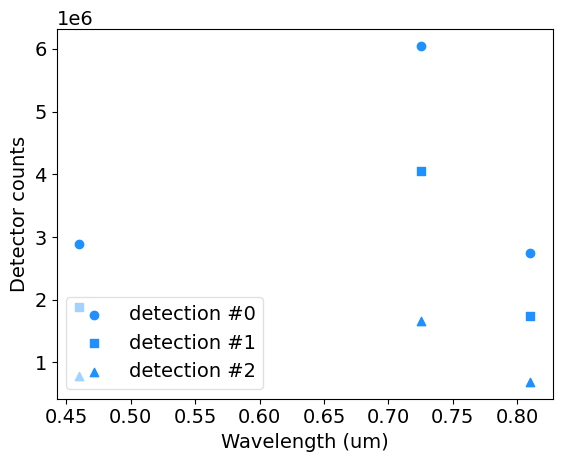

In [331]:
kk = 0
colors = ['dodgerblue', 'deeppink', 'darkred']
markers = ['o', 's', '^']
fig, ax = plt.subplots()

for filter_name in filter_names:
        if kk == 0:
                first_filter = True
        else:
                first_filter = False

        filter_data, lambda_min, lambda_max = detector.get_filter_info(filter_name) # assigns filter info to detector parameters (wavelength, bandwidth)
        print(f"\n\nFilter: {filter_name} [{lambda_min} - {lambda_max} um]")

        # ---- get noisy and not noisy photometric detections for simulated system ----
        noisy_detections, detections_photon_rates, SNRs, phases = phot.get_detections_counts_color(n_epochs, xyzs=all_coords, 
                                                                                                   Star=star, System=system, 
                                                                                                     Detector=detector, 
                                                                                                     filter_name=filter_name,
                                                                                                     spectrum_dir=spectrum_dir,
                                                                                                     first_filter=first_filter)
        print('noisy_detections: ', noisy_detections)
        print("detections_photon_rates: ", detections_photon_rates)
        print('SNRs: ', SNRs)
        print('phases: ', phases)

        kk += 1
        
        # for just 1 planet:
        for detection in range(len(noisy_detections[0])):
                plt.scatter((lambda_max + lambda_min)/2, noisy_detections[0][detection], c=colors[0], 
                            label=f'detection #{detection}', marker=markers[detection]) 
        plt.ylabel('Detector counts')
        plt.xlabel('Wavelength (um)')

        # Get only first three instances of marker labels
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='lower left', framealpha=0.6)


In [332]:
system.planets[0].phase_angles

[110.72469297858804, -124.7810531318937, -137.96589170639834]

In [333]:
Bfilter_data, Blambda_min, Blambda_max = detector.get_filter_info('B')
Rfilter_data, Rlambda_min, Rlambda_max = detector.get_filter_info('R')
Ifilter_data, Ilambda_min, Ilambda_max = detector.get_filter_info('I')

print('Blambda_min - Blambda_max: ', Blambda_min, '--', Blambda_max)
print('Rlambda_min - Rlambda_max: ', Rlambda_min, '--', Rlambda_max)
print('Ilambda_min - Ilambda_max: ', Ilambda_min, '--', Ilambda_max)

Blambda_min - Blambda_max:  0.36000000000000004 -- 0.56
Rlambda_min - Rlambda_max:  0.5500000000000002 -- 0.9000000000000001
Ilambda_min - Ilambda_max:  0.7000000000000002 -- 0.9200000000000002


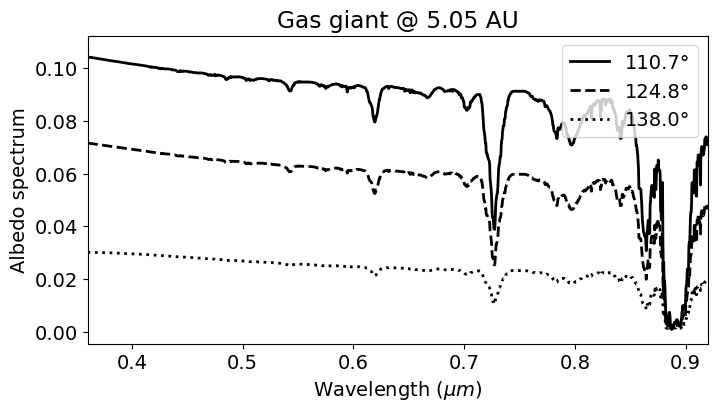

In [334]:
fig, ax = plt.subplots(facecolor='none', figsize=(8,4))
plt.plot(system.planets[0].wavelength[0], system.planets[0].Ag[0], c='k', label=f"{np.abs(system.planets[0].phase_angles[0]):.1f}°", linewidth=2)
plt.plot(system.planets[0].wavelength[1], system.planets[0].Ag[1], c='k', linestyle='dashed', label=f"{np.abs(system.planets[0].phase_angles[1]):.1f}°",
         linewidth=2)
plt.plot(system.planets[0].wavelength[2], system.planets[0].Ag[2], c='k', linestyle='dotted', label=f"{np.abs(system.planets[0].phase_angles[2]):.1f}°",
         linewidth=2)


if system.planets[0].type == "gas_giant":
    titlename = "Gas giant"
if system.planets[0].type == "ice_giant":
    titlename = "Ice giant"
if system.planets[0].type == "rocky":
    titlename = "Rocky"
    
plt.ylabel(f"Albedo spectrum")
plt.xlabel("Wavelength ($\mu m$)")
plt.legend()
plt.title(f"{titlename} @ {system.planets[0].a:.2f} AU")

plt.xlim(0.36, 0.92)
plt.show()


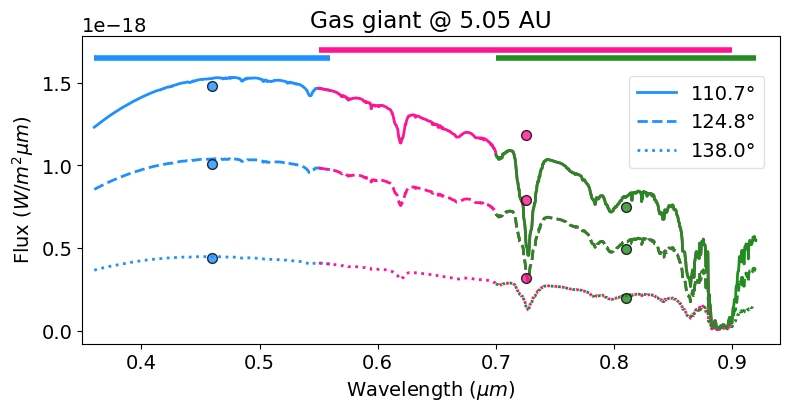

In [ ]:
# Plotting example
linestyles = ['solid', 'dashed', 'dotted']

plt.rcParams.update({'font.size':14})
fig, ax = plt.subplots(figsize=(9,4), facecolor='none')
for i in range(len(system.planets[0].Ag)):  # loop over each detection
    # B filter
    filter_index = 0 # index for grabbing saved filter info from planet.band_fluxes
    # plt.plot(system.planets[0].wavelength[i], system.planets[0].Ag[i], label=system.planets[0].phase_angles[i]) # albedo spectrum
    plt.plot(system.planets[0].band_fluxes[filter_index]['planet_wavelength_in_filter'], system.planets[0].band_fluxes[filter_index]['Fp_specs_in_filter'][i],
             linestyle=linestyles[i], color='dodgerblue', linewidth=2, label=f"{np.abs(system.planets[0].phase_angles[i]):.1f}°")
    plt.scatter((Blambda_max + Blambda_min)/2,system.planets[0].band_fluxes[filter_index]['Fp_band_avgs'][i], 
                marker='o', s=50, alpha=0.8, c='dodgerblue', edgecolors='k', zorder=3)
    
    # R filter
    filter_index = 1
    plt.plot(system.planets[0].band_fluxes[filter_index]['planet_wavelength_in_filter'], system.planets[0].band_fluxes[filter_index]['Fp_specs_in_filter'][i],
             linestyle=linestyles[i], color='deeppink', linewidth=2)
    plt.scatter((Rlambda_max + Rlambda_min)/2,system.planets[0].band_fluxes[filter_index]['Fp_band_avgs'][i], 
                marker='o', s=50, alpha=0.8, c='deeppink', edgecolors='k', zorder=3)
    
    # I filter
    filter_index = 2
    plt.plot(system.planets[0].band_fluxes[filter_index]['planet_wavelength_in_filter'], system.planets[0].band_fluxes[filter_index]['Fp_specs_in_filter'][i],
             linestyle=linestyles[i], color='forestgreen', linewidth=2)
    plt.scatter((Ilambda_max + Ilambda_min)/2,system.planets[0].band_fluxes[filter_index]['Fp_band_avgs'][i], 
                marker='o', s=50, alpha=0.8, c='forestgreen', edgecolors='k', zorder=3)
    
# # Add bars for passbands
ax.hlines(1.65e-18, xmin=Blambda_min, xmax=Blambda_max, color='dodgerblue', linewidth=4) # blue filter
ax.hlines(1.7e-18, xmin=Rlambda_min, xmax=Rlambda_max, color='deeppink', linewidth=4)
ax.hlines(1.65e-18, xmin=Ilambda_min, xmax=Ilambda_max, color='forestgreen', linewidth=4)

if system.planets[0].type == "gas_giant":
    titlename = "Gas giant"
if system.planets[0].type == "ice_giant":
    titlename = "Ice giant"
if system.planets[0].type == "rocky":
    titlename = "Rocky"

plt.title(f"{titlename} @ {system.planets[0].a:.2f} AU")
plt.ylabel(f"Flux ($W/m^2 \mu m$)")#[{system.planets[0].band_fluxes[0]['Fp_specs_in_filter'][0].unit}]")
plt.xlabel("Wavelength ($\mu m$)")
plt.xlim(0.35, 0.94)
plt.legend(bbox_to_anchor=(0.77, 0.9), framealpha=0.6, fontsize=14) # loc='upper right', x

In [321]:
import ranking

In [322]:
# Test new ranking functions
n_planets = 3
for filter in filter_names:
    print("Filter: ", filter)
    output_file = f"test_deconfuser_output_2025-06-23_145418_11systems_medi_{filter_name}.txt"
    confused_systems = ranking.PhotometryRanking(filepath=f"../output_files/{output_file}", n_planets=n_planets)
    df_confused = confused_systems.get_top_group_options()  # iterate over options with multiple groups
    print('df_confused.system.unique()')
    print(df_confused.system.unique())
    df_ranked = confused_systems.top_ranked_partition()     # Get top ranked partition in each system
    df_recombined = confused_systems.combine_and_cleanup(save_file=False)  # Combine original and ranked dataframes
    # If you want to calculate percent difference between simulated and fit orbits:
    df_final = confused_systems.orbit_percent_diff()      
    n_top_a_is_best, n_top_e_is_best, n_top_i_is_best = ranking.check_ranking_by_planet(df_final, n_planets)

    # df_final_wperc = confused_systems.final_recombined(save_file=False)    
    if filter == 'B':
        df_B = df_final
    if filter == 'R':
        df_R = df_final
    if filter == 'I':
        df_I = df_final
df_B.columns

Filter:  B


FileNotFoundError: [Errno 2] No such file or directory: '../output_files/test_deconfuser_output_2025-06-23_145418_11systems_medi_I.txt'

In [ ]:
df_merged = ranking.combine_filter_dfs(df_B, df_R, df_I, 'B', 'R', 'I')
# ranking.save_df(df_merged, 
                # filename="/Users/shasler/Documents/Projects/deconfusion_color/ranking_files/all_filters.txt")
df_merged

,system_original,n_planets_original,planet_original,planet_type_original,n_orbit_options_original,a_original,e_original,i_original,o_original,O_original,...,L_partition_I,L_partition_list_I,ranking_I,top_ranked_partition_I,best_a_I,best_e_I,best_i_I,best_a_count_I,best_e_count_I,best_i_countI
0,2,3,1,ice_giant,1.0,[4.877807857537793],[0.07241383964640738],[1.05968359253671],[1.9645550688852937],[0.7630755707917197],...,NaN,NaN,3.0,False,True,False,False,1,1,0
1,2,3,1,ice_giant,1.0,[4.877807857537793],[0.07241383964640738],[1.05968359253671],[1.9645550688852937],[0.7630755707917197],...,NaN,NaN,5.0,False,True,False,False,1,0,0
2,2,3,1,ice_giant,1.0,[4.877807857537793],[0.07241383964640738],[1.05968359253671],[1.9645550688852937],[0.7630755707917197],...,NaN,NaN,6.0,False,True,False,False,1,0,0
3,2,3,1,ice_giant,1.0,[4.877807857537793],[0.07241383964640738],[1.05968359253671],[1.9645550688852937],[0.7630755707917197],...,NaN,NaN,4.0,False,True,False,False,1,0,0
4,2,3,1,ice_giant,1.0,[4.877807857537793],[0.07241383964640738],[1.05968359253671],[1.9645550688852937],[0.7630755707917197],...,NaN,NaN,3.0,False,True,False,False,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,2,3,1,ice_giant,1.0,[3.4657457783470687],[0.09778277786748811],[0.9641126055332809],[-0.40393480992032527],[0.9168741479181178],...,NaN,NaN,6.0,False,False,False,False,0,0,0
146,2,3,1,ice_giant,1.0,[3.4657457783470687],[0.09778277786748811],[0.9641126055332809],[-0.40393480992032527],[0.9168741479181178],...,NaN,NaN,3.0,False,False,False,False,0,0,0
147,2,3,1,ice_giant,1.0,[3.4657457783470687],[0.09778277786748811],[0.9641126055332809],[-0.40393480992032527],[0.9168741479181178],...,NaN,NaN,6.0,False,False,False,False,0,0,0
148,2,3,2,ice_giant,2.0,"[0.8329153244055124, 1.1946620047301781]","[0.0924361641590803, 0.09831228876620145]","[1.8746312241484877, 1.3051550081947147]","[-0.502972906360375, 0.13422909466520583]","[-0.13372161127466056, -0.039871885056593774]",...,NaN,NaN,6.0,False,False,False,False,0,0,0
